In [16]:
import matplotlib.pyplot as plt
import numpy as np
from openai import OpenAI
client = OpenAI()

from FantAIno.utils.genius_utils import get_album_lyrics

## Embeddings Sample

In [2]:
response = client.embeddings.create(
    input="Your text string goes here",
    model="text-embedding-3-small"
)

In [3]:
response.data[0].embedding

[0.005115509033203125,
 0.017242431640625,
 -0.018768310546875,
 -0.0185699462890625,
 -0.047271728515625,
 -0.030303955078125,
 0.027679443359375,
 0.0036468505859375,
 0.01125335693359375,
 0.006404876708984375,
 -0.001678466796875,
 0.0158233642578125,
 -0.001255035400390625,
 -0.007843017578125,
 0.0599365234375,
 0.050323486328125,
 -0.0275421142578125,
 0.00994110107421875,
 -0.04034423828125,
 0.050018310546875,
 -0.00043082237243652344,
 0.030181884765625,
 -0.0137176513671875,
 0.032958984375,
 0.0173187255859375,
 0.0167999267578125,
 -0.0017566680908203125,
 0.0204620361328125,
 0.040802001953125,
 -0.0377197265625,
 -0.026153564453125,
 -0.050048828125,
 0.024200439453125,
 -0.05523681640625,
 -0.0322265625,
 0.0423583984375,
 0.064697265625,
 0.01473236083984375,
 -0.01568603515625,
 -0.041351318359375,
 0.02215576171875,
 0.007411956787109375,
 0.044952392578125,
 0.0070953369140625,
 -0.0240936279296875,
 0.05242919921875,
 -0.0200958251953125,
 -0.0322265625,
 0.0162811

In [4]:
len(response.data[0].embedding)

1536

In [5]:
response_large = client.embeddings.create(
    input="Your text string goes here",
    model="text-embedding-3-large"
)
len(response_large.data[0].embedding)

3072

## Extract Genius Lyrics

In [6]:
logic_under_pressure = get_album_lyrics("Logic", "Under Pressure")

In [7]:
logic_under_pressure

{'artist': 'Logic',
 'album': 'Under Pressure',
 'tracks': {'Intro (Under Pressure)': "[Intro: Steve Wyreman]\nAight, or higher probably, right?\nFuck it, just record it, who cares?\nOne, two\n\n[Verse]\nI just wanna make these music lovers remember again\nWhile the haters fall back like September again\nI was hoping 3 Stacks and Big would assemble again\nDrop the politics and bring us together again\nMaybe if I go platinum they'll remember me then\nMaybe if I go platinum they'll remember me then, yeah\nYeah, yeah, yeah, yeah, yeah, yeah, yeah\nYeah, \nyeah, yeah, yeah, yeah, yeah, yeah, yeah\nBut I'm not defined by the sales of my first week\n'Cause in my mind, the only way I fail if my verse weak\nAs I look in the crowd and see thousands of different faces\nCompiled of different races, gathering from different places\nI just contemplate, shout out to those who can relate\nAnd even though it gets hard, I know my fate\nWith my train of thought racing like a runaway freight\nLiving life

In [11]:
album_lyrics_string = "\n\n".join([f"{k}: {v}" for k, v in logic_under_pressure['tracks'].items()])
album_lyrics_string

'Intro (Under Pressure): [Intro: Steve Wyreman]\nAight, or higher probably, right?\nFuck it, just record it, who cares?\nOne, two\n\n[Verse]\nI just wanna make these music lovers remember again\nWhile the haters fall back like September again\nI was hoping 3 Stacks and Big would assemble again\nDrop the politics and bring us together again\nMaybe if I go platinum they\'ll remember me then\nMaybe if I go platinum they\'ll remember me then, yeah\nYeah, yeah, yeah, yeah, yeah, yeah, yeah\nYeah, \nyeah, yeah, yeah, yeah, yeah, yeah, yeah\nBut I\'m not defined by the sales of my first week\n\'Cause in my mind, the only way I fail if my verse weak\nAs I look in the crowd and see thousands of different faces\nCompiled of different races, gathering from different places\nI just contemplate, shout out to those who can relate\nAnd even though it gets hard, I know my fate\nWith my train of thought racing like a runaway freight\nLiving life to the fullest until I hit up them gates, it\'s like\n\n[

One problem. This entire sequence is about 14K tokens. An embedding model can at max take 8192 tokens. Even then, throwing all song text in a single embedding is pretty one-dimensional. Albums have range, where each song has the potential to touch on a different theme.

Through a chunking process, we can create an embedding for each song.

In [14]:
album_embeddings = np.empty((len(logic_under_pressure['tracks']), len(response.data[0].embedding)))

for i, (track, lyrics) in enumerate(logic_under_pressure['tracks'].items()):
    response_embedding = client.embeddings.create(
        input=lyrics,
        model="text-embedding-3-small"
    )
    album_embeddings[i] = response_embedding.data[0].embedding

In [15]:
album_embeddings

array([[ 2.99835205e-02, -2.37121582e-02, -3.54003906e-02, ...,
        -5.12123108e-04, -9.20104980e-03,  1.08261108e-02],
       [ 2.61993408e-02, -2.20031738e-02, -7.14111328e-02, ...,
         1.65710449e-02,  4.97436523e-03,  6.11495972e-03],
       [ 3.12500000e-02, -1.18408203e-02, -5.44433594e-02, ...,
         2.36816406e-02, -1.09100342e-02,  3.39355469e-02],
       ...,
       [ 3.99169922e-02, -1.28479004e-02, -5.39550781e-02, ...,
         3.24096680e-02, -1.91497803e-02, -5.16176224e-05],
       [ 4.11987305e-02, -2.26898193e-02, -6.90307617e-02, ...,
        -1.26800537e-02,  3.47328186e-03,  2.70233154e-02],
       [ 2.82745361e-02,  1.07192993e-02, -4.78210449e-02, ...,
         1.30996704e-02,  1.35345459e-02,  3.56101990e-03]],
      shape=(12, 1536))

Now we have the embeddings for each song! Let's visualize each of Logic's Under Pressure songs on a heatmap (code mostly assisted with Cursor).

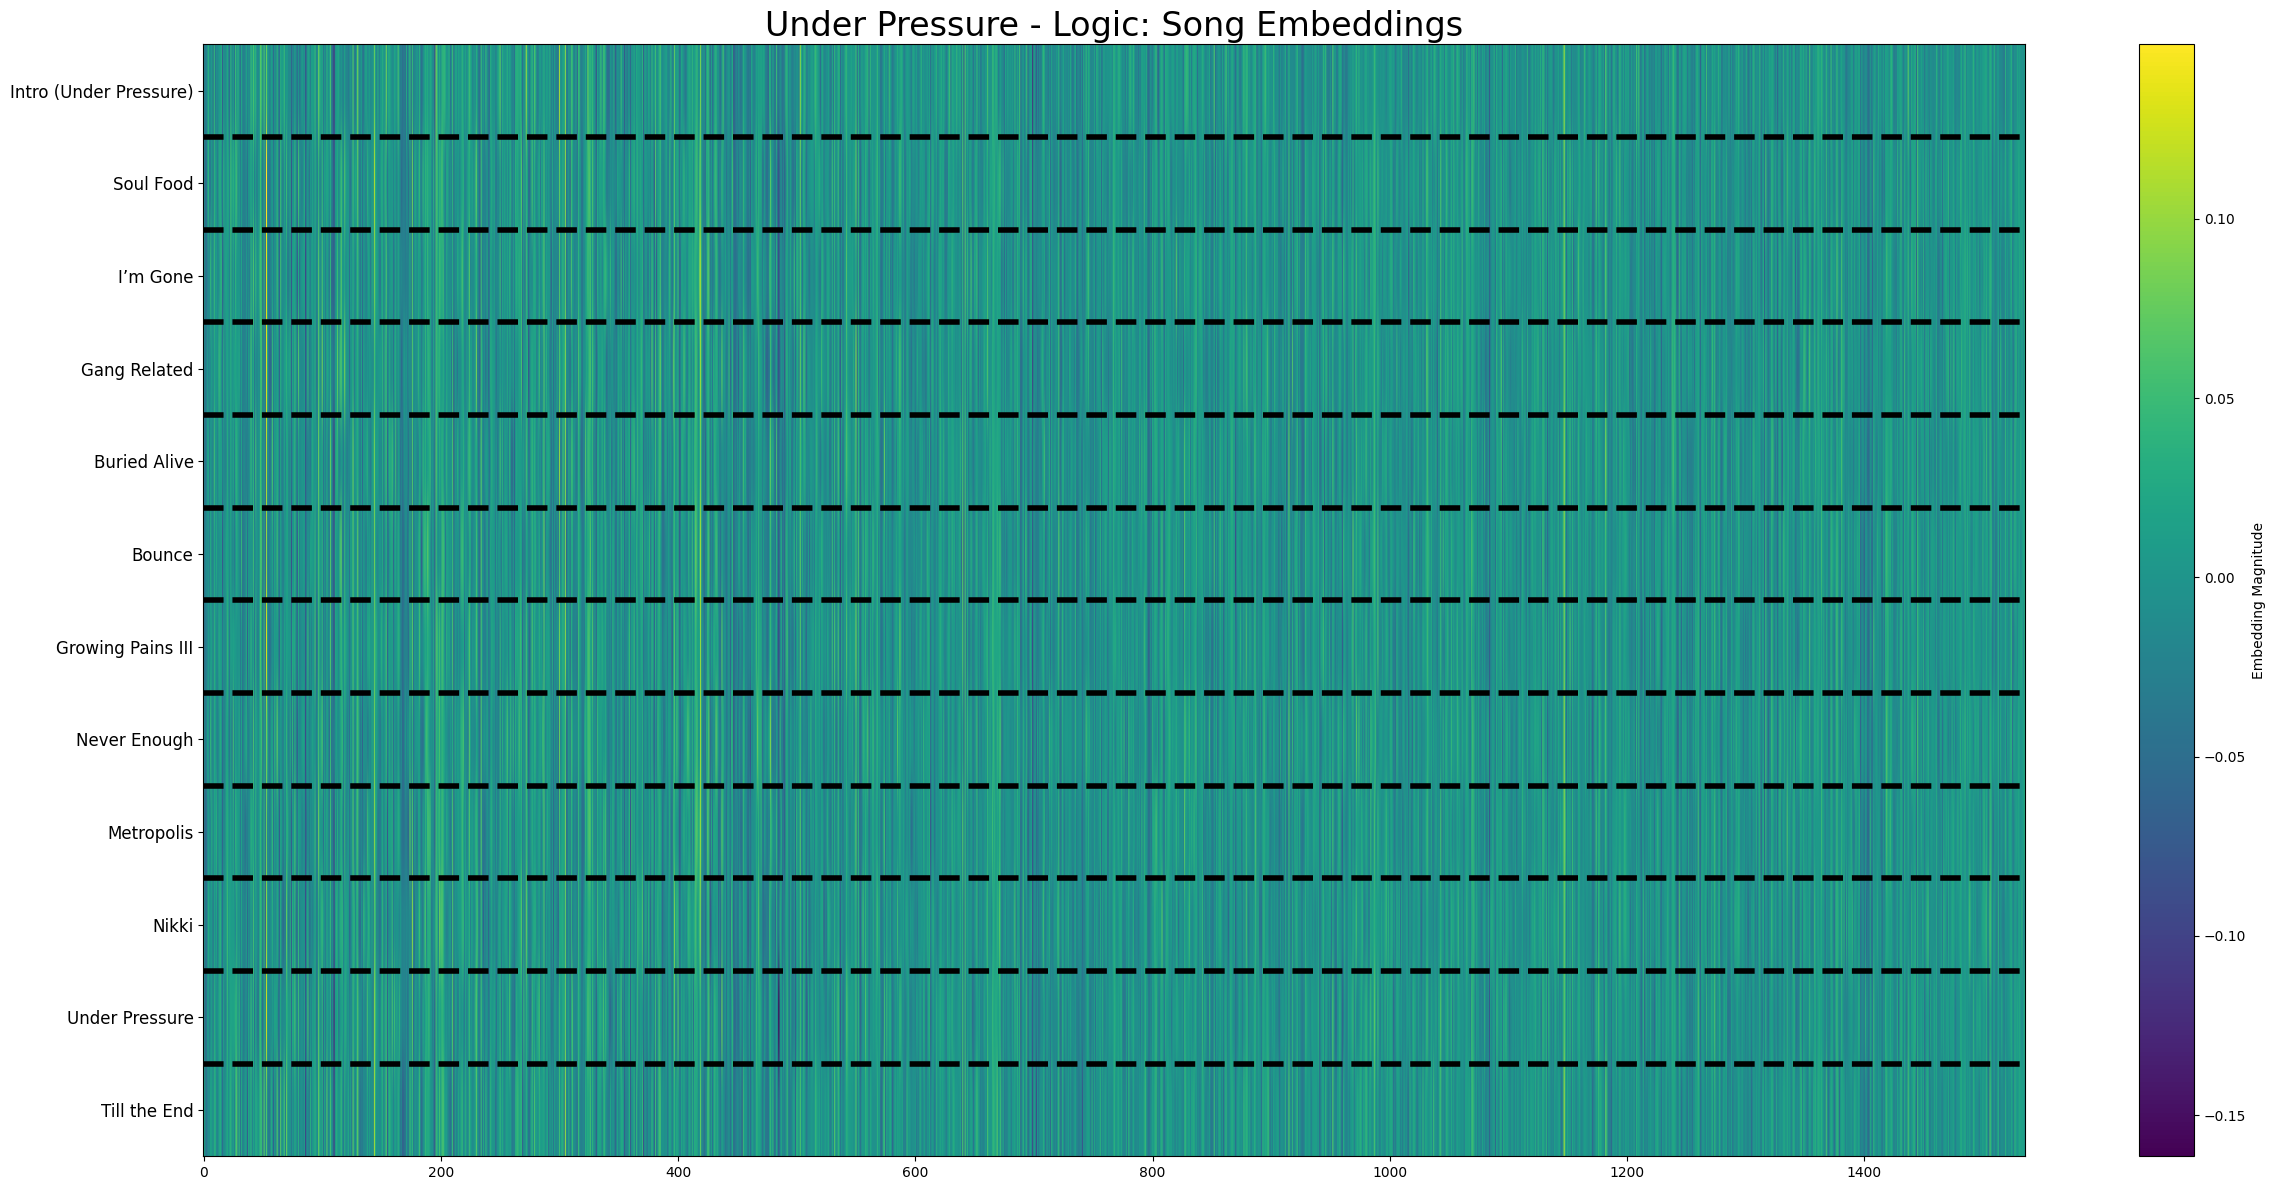

In [50]:
fig, ax = plt.subplots(figsize=(25, 12))
im = ax.imshow(album_embeddings, aspect='auto')
ax.set_title("Under Pressure - Logic: Song Embeddings", fontsize=24)
ax.set_yticks(np.arange(album_embeddings.shape[0]))
ax.set_yticklabels(list(logic_under_pressure['tracks'].keys()), fontsize=12)

# Insert a horizontal black dashed line as a divider between each song
for y in range(1, album_embeddings.shape[0]):
    ax.axhline(y - 0.5, color='black', linestyle='--', linewidth=4)

plt.colorbar(im, label='Embedding Magnitude')
plt.tight_layout()
plt.show()

It seems like a lot of the songs share similar positive or negative symbols along certain embedding dimensions. We could create an album level "embedding" by taking a row sum over all embeddings. This sum could contain relevant signal about how much this specific embedding dimension is represented by the album.

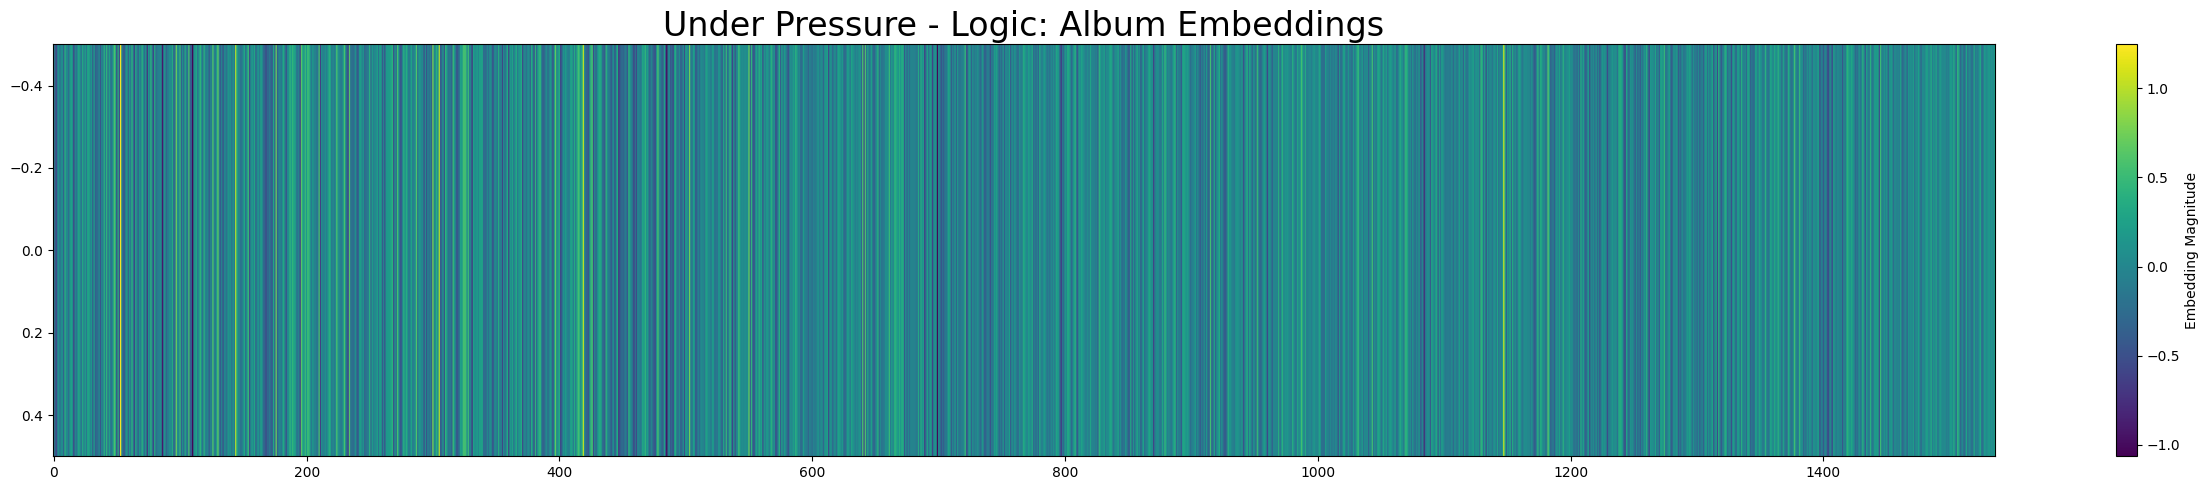

In [52]:
fig, ax = plt.subplots(figsize=(25, 5))
im = ax.imshow(album_embeddings.sum(axis=0, keepdims=True), aspect='auto')
ax.set_title("Under Pressure - Logic: Album Embeddings", fontsize=24)
plt.colorbar(im, label='Embedding Magnitude')
plt.tight_layout()
plt.show()

In [57]:
for threshold in np.linspace(0.0, 1.0, 11):
    print(f"Threshold: {threshold}")
    print(np.mean(np.abs(album_embeddings.sum(axis=0, keepdims=True)) >= threshold))


Threshold: 0.0
1.0
Threshold: 0.1
0.6770833333333334
Threshold: 0.2
0.4166666666666667
Threshold: 0.30000000000000004
0.228515625
Threshold: 0.4
0.11393229166666667
Threshold: 0.5
0.057942708333333336
Threshold: 0.6000000000000001
0.01953125
Threshold: 0.7000000000000001
0.009765625
Threshold: 0.8
0.005859375
Threshold: 0.9
0.005859375
Threshold: 1.0
0.0032552083333333335


Note: Anthony Fantano has his finger on the pulse of current events and politics. This means the following note from OpenAI highlights a possible limitation of over-relying on these embeddings:

<div align="center">
"the text-embedding-3-large and text-embedding-3-small models lack knowledge of events that occurred after September 2021."
</div>